In [ ]:
import torch

In [ ]:
from torch import nn

In [ ]:
from torch.utils.data import DataLoader, Subset

In [ ]:
from torchvision import datasets, transforms

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from torchvision.datasets import MNIST

Device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 35.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.5MB/s]


Batch: (64, 1, 28, 28) Pixel range: 0.0 1.0


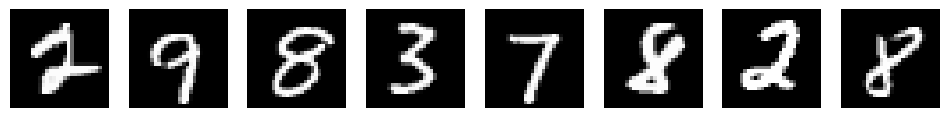

In [ ]:

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
EPOCHS = 5  # Start with 1 to check your code, then train for 5.
LATENT_CHANNELS = 8
print("Device:", device)

train_data = datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())
# Fixed random subsets keep the exercise small and comparisons repeatable.
g = torch.Generator().manual_seed(42)
train_data = Subset(train_data, torch.randperm(len(train_data), generator=g)[:5000].tolist())
test_data = Subset(test_data, torch.randperm(len(test_data), generator=g)[:1000].tolist())
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
images, labels = next(iter(train_loader))
print("Batch:", tuple(images.shape), "Pixel range:", images.min().item(), images.max().item())
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax, img in zip(axes, images[:8]):
    ax.imshow(img[0], cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.show()

In [ ]:
class Encoder(nn.Module):
    def __init__(self, latent_channels=8):
        super().__init__()
        print(f"Encoder initialized with latent_channels: {latent_channels}") # Diagnostic print
        self.network = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, latent_channels, kernel_size=1),
            nn.ReLU()
        )


    def forward(self, x):
        return self.network(x)

class Decoder(nn.Module):
    def __init__(self, latent_channels=8):
        super().__init__()
        print(f"Decoder initialized with latent_channels: {latent_channels}") # Diagnostic print
        self.network = nn.Sequential(
            nn.ConvTranspose2d(latent_channels, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
            )

    def forward(self, z):
        return self.network(z)
class ImageEncoderDecoder(nn.Module):
    def __init__(self, latent_channels=8):
        super().__init__()
        self.encoder = Encoder(latent_channels)
        self.decoder = Decoder(latent_channels)

    def forward(self, x):
        z = self.encoder(x)
        print(f"Encoder output z shape: {z.shape}") # Diagnostic print
        return self.decoder(z), z

In [ ]:

# Shape and range checks: run these before training.
model = ImageEncoderDecoder(LATENT_CHANNELS).to(device)
x = torch.rand(4, 1, 28, 28, device=device)
with torch.no_grad():
    reconstruction, z = model(x)
assert z.shape == (4, LATENT_CHANNELS, 7, 7), "Check encoder stride/padding/channels"
assert reconstruction.shape == x.shape, "Check decoder output_padding"
assert torch.isfinite(reconstruction).all(), "Output contains nonfinite values"
assert ((reconstruction >= 0) & (reconstruction <= 1)).all(), "Check output activation"
print("Input:", tuple(x.shape), "Latent:", tuple(z.shape), "Output:", tuple(reconstruction.shape))
print("Shape and range checks passed")

Encoder initialized with latent_channels: 8
Decoder initialized with latent_channels: 8
Encoder output z shape: torch.Size([4, 8, 7, 7])
Input: (4, 1, 28, 28) Latent: (4, 8, 7, 7) Output: (4, 1, 28, 28)
Shape and range checks passed


In [ ]:
def train_step(model, images, optimizer, criterion):
    model.train() # Set the model to training mode
    images = images.to(device) # Move images to the device

    # Forward pass
    reconstruction, z = model(images)

    # Calculate loss
    loss = criterion(reconstruction, images)

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

Encoder initialized with latent_channels: 8
Decoder initialized with latent_channels: 8
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.Size([40, 8, 7, 7])
Untrained held-out MSE: 0.18605
Encoder output z shape: torch.Size([64, 8, 7, 7])
Encoder output z shape: torch.

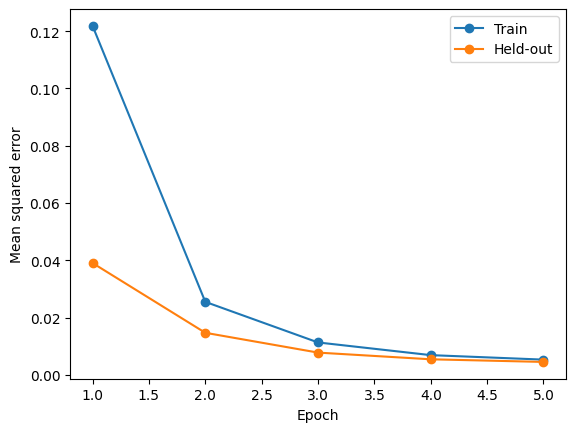

In [ ]:
criterion = nn.MSELoss()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    for images, _ in loader:
        images = images.to(device)
        reconstruction, _ = model(images)
        total_loss += criterion(reconstruction, images).item() * images.size(0)
    return total_loss / len(loader.dataset)

# Re-running this cell starts a fresh model and optimizer.
torch.manual_seed(42)
model = ImageEncoderDecoder(LATENT_CHANNELS).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
initial_mse = evaluate(model, test_loader)
print(f"Untrained held-out MSE: {initial_mse:.5f}")
history = {"train": [], "test": []}
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        total_loss += train_step(model, images, optimizer, criterion) * images.size(0)
    history["train"].append(total_loss / len(train_loader.dataset))
    history["test"].append(evaluate(model, test_loader))
    print(f"Epoch {epoch + 1}: train MSE={history['train'][-1]:.5f}, "
          f"held-out MSE={history['test'][-1]:.5f}")

plt.plot(range(1, EPOCHS + 1), history["train"], marker="o", label="Train")
plt.plot(range(1, EPOCHS + 1), history["test"], marker="o", label="Held-out")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.legend()
plt.show()

Encoder output z shape: torch.Size([8, 8, 7, 7])


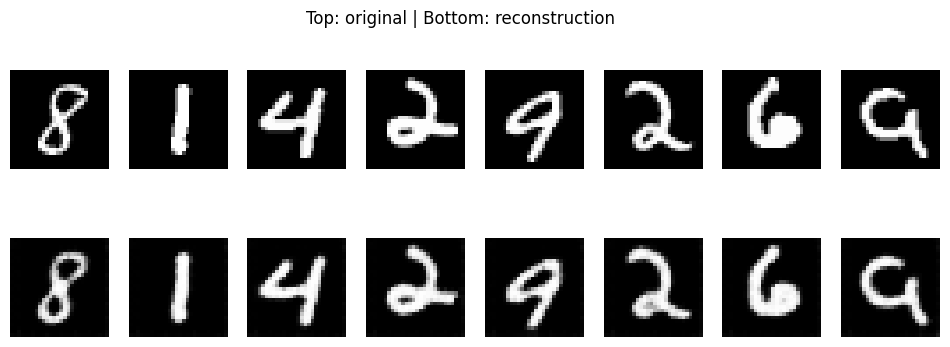

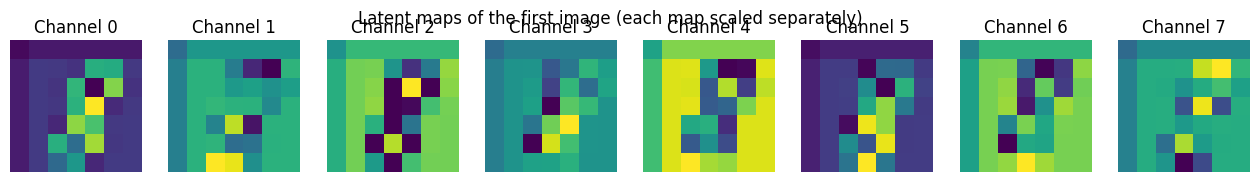

In [ ]:
model.eval()
examples, _ = next(iter(test_loader))
with torch.no_grad():
    reconstructed, latents = model(examples[:8].to(device))
reconstructed, latents = reconstructed.cpu(), latents.cpu()
fig, axes = plt.subplots(2, 8, figsize=(12, 4))
for i in range(8):
    axes[0, i].imshow(examples[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, i].imshow(reconstructed[i, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[1, i].axis("off")
fig.suptitle("Top: original | Bottom: reconstruction")
plt.show()

count = min(LATENT_CHANNELS, 8)
fig, axes = plt.subplots(1, count, figsize=(2 * count, 2), squeeze=False)
for i in range(count):
    axes[0, i].imshow(latents[0, i], cmap="viridis")
    axes[0, i].set_title(f"Channel {i}")
    axes[0, i].axis("off")
fig.suptitle("Latent maps of the first image (each map scaled separately)")
plt.show()
